In [2]:
import numpy as np
import pandas as pd
from skimage.draw    import polygon
from sklearn.cluster         import KMeans
from sklearn.preprocessing   import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import pickle
import math

import tensorflow as tf
from tensorflow.keras        import models, Input
import matplotlib.colors     as mcolors

WINDOW, HALF = 25, 24
TRAIN_DAYS = (
    list(range(366,  731))  
)
TEST_DAYS  = (
    list(range(2557, 2622))   # 2007
)
ALL_DAYS   = TRAIN_DAYS + TEST_DAYS
RNG        = 42
KM         = 10
EPOCHS     = 40
BATCH      = 256
REGIONS9   = ["NW","N","NE","W","C","E","SW","S","SE"]
ROI_TYPES  = ["COL","CL","COH","NROI"]
TYPE_COLORS = {"COL":"red","CL":"blue","COH":"green","NROI":"orange"}

def create_roi_mask(df, day, shape):
    mask = np.zeros(shape, dtype=np.int8)
    day_data = df[df["Day"]==day]
    for name, grp in day_data.groupby("Name"):
        pts = grp[["x","y"]].values
        if len(pts)<3:
            continue
        xs, ys = pts[:,0].astype(np.int32), pts[:,1].astype(np.int32)
        rows = (shape[0]-1) - ys
        cols = xs
        rr, cc = polygon(rows, cols, shape=shape)
        code = ROI_TYPES.index(grp["Label"].iat[0]) + 1
        mask[rr,cc] = code
    return mask

def load_grids(day):
    P = pd.read_csv(f"pressure/day{day}.txt", sep=r"\s+", header=None).values.astype(np.float32)
    W = pd.read_csv(f"wind/day{day}.txt",    sep=r"\s+", header=None).values.astype(np.float32)
    return P, W

type_to_label = {"COL": 0, "CL": 1, "COH": 2, "NROI": 3, "BG": 4}
label_to_type = {v: k for k, v in type_to_label.items()}

cmap_types = mcolors.ListedColormap(["lightgrey"] + [TYPE_COLORS[t] for t in ROI_TYPES])
type_code  = {t:i+1 for i,t in enumerate(ROI_TYPES)}

roi_df = pd.read_csv("roi_data_with_status.csv")
required = {"Day","Name","x","y","Label"}
if not required.issubset(roi_df.columns):
    raise RuntimeError(f"roi_data_with_status.csv must contain columns: {required}")

with open('train_patches.pkl', 'rb') as f:
        tr_data = pickle.load(f)

with open('test_patches.pkl', 'rb') as f:
        te_data = pickle.load(f)

X_basic     = np.vstack([tr_data['X_basic'], te_data['X_basic']])
y_all       = np.concatenate([tr_data['y_all'], te_data['y_all']])
coords      = np.vstack([tr_data['coords'], te_data['coords']])
types_arr   = np.concatenate([tr_data['types_arr'], te_data['types_arr']])
regions_codes = np.concatenate([tr_data['regions_codes'], te_data['regions_codes']])
days_arr    = np.concatenate([tr_data['days_arr'], te_data['days_arr']])

c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


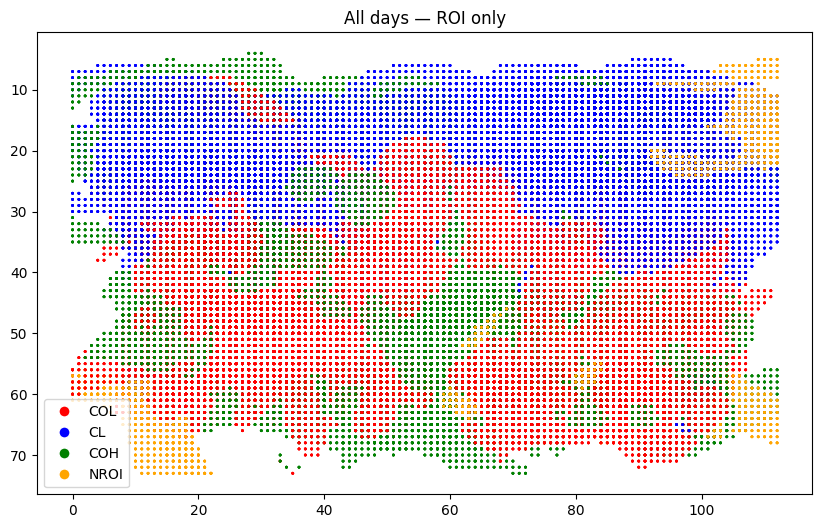

In [3]:
import matplotlib.pyplot as plt

roi_mask = np.array([t != "BG" for t in types_arr])

all_x  = coords[roi_mask, 0]
all_y  = coords[roi_mask, 1]
colors = [TYPE_COLORS[t] for t in types_arr[roi_mask]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(all_x, all_y, c=colors, s=1)

patches = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8)
           for k, v in TYPE_COLORS.items()]
ax.legend(handles=patches)
ax.set_title("All days — ROI only")
ax.invert_yaxis()
plt.show()

In [4]:
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.metrics import accuracy_score
RNG        = 42
KNN         = 5

train_mask = np.isin(days_arr, TRAIN_DAYS)
test_mask  = np.isin(days_arr, TEST_DAYS)

X_feat_tr, X_feat_te = X_basic[train_mask], X_basic[test_mask]
y_tr,      y_te       = y_all[train_mask],  y_all[test_mask]
coords_tr, coords_te  = coords [train_mask], coords [test_mask]
types_tr,  types_te   = types_arr[train_mask], types_arr[test_mask]
days_tr,   days_te    = days_arr[train_mask], days_arr[test_mask]

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_feat_tr)
X_te = scaler.transform(X_feat_te)

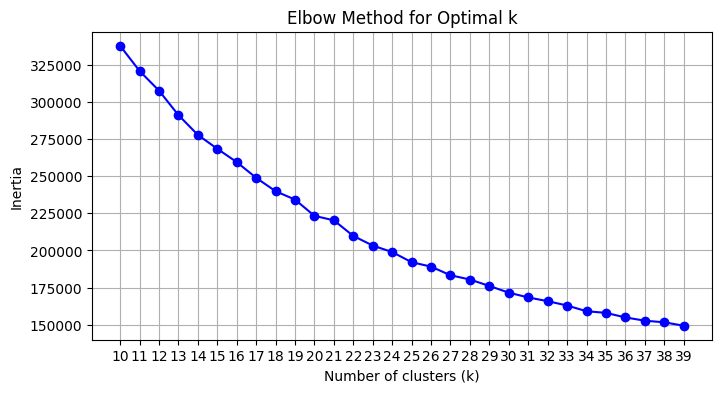

In [7]:
inertias = []
k_range = range(10, 40)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RNG, n_init=10)
    km.fit(X_tr[:50_000])  # subsample for speed
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

roi_count = (y_tr != 4).sum()

rus = RandomUnderSampler(
    sampling_strategy={
        0: int((y_tr == 0).sum()),  
        1: int((y_tr == 1).sum()),  
        2: int((y_tr == 2).sum()),  
        3: int((y_tr == 3).sum()),  
        4: roi_count * 1           
    },
    random_state=RNG
)

X_feat_tr_bal, y_tr_bal = rus.fit_resample(X_feat_tr, y_tr)

print("Balanced class counts:", np.bincount(y_tr_bal))

Balanced class counts: [  40280   38840   18560    5868 1035480]
